In [1]:
!pip install datasets transformers accelerate

In [2]:
from datasets import load_dataset
medhallu = load_dataset("UTAustin-AIHealth/MedHallu", "pqa_labeled")
print(medhallu)
print(medhallu['train'][0])

README.md: 0.00B [00:00, ?B/s]

pqa_labeled/train-00000-of-00001.parquet:   0%|          | 0.00/1.12M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['Question', 'Knowledge', 'Ground Truth', 'Difficulty Level', 'Hallucinated Answer', 'Category of Hallucination'],
        num_rows: 1000
    })
})
{'Question': 'Do mitochondria play a role in remodelling lace plant leaves during programmed cell death?', 'Knowledge': ['Programmed cell death (PCD) is the regulated death of cells within an organism. The lace plant (Aponogeton madagascariensis) produces perforations in its leaves through PCD. The leaves of the plant consist of a latticework of longitudinal and transverse veins enclosing areoles. PCD occurs in the cells at the center of these areoles and progresses outwards, stopping approximately five cells from the vasculature. The role of mitochondria during PCD has been recognized in animals; however, it has been less studied during PCD in plants.', 'The following paper elucidates the role of mitochondrial dynamics during developmentally regulated PCD in vivo in A. madagascariensis. 

In [3]:
from kaggle_secrets import UserSecretsClient
hf_token = UserSecretsClient().get_secret("HF_TOKEN")
from huggingface_hub import login
login(token=hf_token)

In [4]:
from huggingface_hub import whoami
print(whoami())

{'type': 'user', 'id': '67991610e5cc114ea61a165e', 'name': 'vignesh2375', 'fullname': 'Vignesh P', 'email': 'vignesh23557@gmail.com', 'emailVerified': True, 'canPay': False, 'billingMode': 'prepaid', 'periodEnd': 1790812800, 'isPro': False, 'avatarUrl': '/avatars/d4242c21788d355771f96739ce120577.svg', 'orgs': [], 'auth': {'type': 'access_token', 'accessToken': {'displayName': 'medhallu-hallucination-detection', 'role': 'read', 'createdAt': '2026-08-29T06:01:17.548Z'}}}


In [5]:
from transformers import pipeline

detector = pipeline(
    "text-generation",
    model="microsoft/Phi-3-mini-4k-instruct",
    device_map="auto",
    torch_dtype="auto"
)

config.json:   0%|          | 0.00/967 [00:00<?, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/195 [00:00<?, ?it/s]

...

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/306 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/599 [00:00<?, ?B/s]

In [6]:
import random

samples = medhallu['train'].select(range(5))

for row in samples:
    use_hallucinated = random.choice([True, False])
    answer_to_test = row['Hallucinated Answer'] if use_hallucinated else row['Ground Truth']
    actual_label = "HALLUCINATED" if use_hallucinated else "REAL"

    prompt = f"""Question: {row['Question']}
Answer: {answer_to_test}

Is this answer factually correct or is it hallucinated (made up)? Reply with only one word: CORRECT or HALLUCINATED."""

    messages = [{"role": "user", "content": prompt}]
    response = detector(messages, max_new_tokens=10, do_sample=False)
    model_says = response[0]['generated_text'][-1]['content'].strip()

    print(f"Actual: {actual_label} | Model said: {model_says}")
    print("---")

The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
Passing `generation_config` together with generation-related arguments=({'do_sample', 'max_new_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Both `max_new_tokens` (=10) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=10) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Actual: HALLUCINATED | Model said: CORRECT
---


Both `max_new_tokens` (=10) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Actual: REAL | Model said: CORRECT
---


Both `max_new_tokens` (=10) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Actual: HALLUCINATED | Model said: CORRECT
---


Both `max_new_tokens` (=10) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Actual: REAL | Model said: CORRECT
---
Actual: HALLUCINATED | Model said: CORRECT
---


In [7]:
import random
import pandas as pd

random.seed(42)  # so your results are reproducible - important for a paper
samples = medhallu['train'].select(range(200))

results = []

for i, row in enumerate(samples):
    use_hallucinated = random.choice([True, False])
    answer_to_test = row['Hallucinated Answer'] if use_hallucinated else row['Ground Truth']
    actual_label = "HALLUCINATED" if use_hallucinated else "REAL"

    prompt = f"""Question: {row['Question']}
Answer: {answer_to_test}

Is this answer factually correct or is it hallucinated (made up)? Reply with only one word: CORRECT or HALLUCINATED."""

    messages = [{"role": "user", "content": prompt}]
    response = detector(messages, max_new_tokens=10, do_sample=False)
    model_says = response[0]['generated_text'][-1]['content'].strip()

    results.append({
        "question": row['Question'],
        "actual_label": actual_label,
        "model_prediction": model_says,
        "difficulty": row['Difficulty Level']
    })

    if i % 20 == 0:
        print(f"Processed {i}/200...")

df = pd.DataFrame(results)
df.to_csv("baseline_results.csv", index=False)
print("Done. Saved to baseline_results.csv")
print(df['model_prediction'].value_counts())

Both `max_new_tokens` (=10) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=10) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Processed 0/200...


Both `max_new_tokens` (=10) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=10) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=10) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
Both `max_new_tokens` (=10) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation f

Processed 20/200...


Both `max_new_tokens` (=10) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=10) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=10) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=10) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `ma

...

Processed 160/200...


Both `max_new_tokens` (=10) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=10) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=10) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=10) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `ma

Processed 180/200...


Both `max_new_tokens` (=10) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=10) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=10) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=10) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `ma

Done. Saved to baseline_results.csv
model_prediction
CORRECT          144
HALLUCINATED.     56
Name: count, dtype: int64


In [8]:
df = pd.read_csv("baseline_results.csv")

# clean up trailing punctuation/whitespace so matching works properly
df['model_prediction_clean'] = df['model_prediction'].str.strip().str.rstrip('.').str.upper()
df['actual_label_clean'] = df['actual_label'].str.strip().str.upper()

df['correct'] = df['model_prediction_clean'] == df['actual_label_clean']

overall_accuracy = df['correct'].mean() * 100
print(f"Overall baseline accuracy: {overall_accuracy:.1f}%")

# breakdown: how well did it do on REAL answers vs HALLUCINATED answers separately?
print("\nAccuracy by actual label:")
print(df.groupby('actual_label_clean')['correct'].mean() * 100)

# breakdown by difficulty
print("\nAccuracy by difficulty level:")
print(df.groupby('difficulty')['correct'].mean() * 100)

df.to_csv("baseline_results_analyzed.csv", index=False)

Overall baseline accuracy: 21.0%

Accuracy by actual label:
actual_label_clean
HALLUCINATED    37.168142
REAL             0.000000
Name: correct, dtype: float64

Accuracy by difficulty level:
difficulty
easy      27.419355
hard      11.494253
medium    29.411765
Name: correct, dtype: float64


In [9]:
label_map = {"CORRECT": "REAL", "HALLUCINATED": "HALLUCINATED"}
df['model_prediction_mapped'] = df['model_prediction_clean'].map(label_map)

df['correct'] = df['model_prediction_mapped'] == df['actual_label_clean']

overall_accuracy = df['correct'].mean() * 100
print(f"Overall baseline accuracy: {overall_accuracy:.1f}%")

print("\nAccuracy by actual label:")
print(df.groupby('actual_label_clean')['correct'].mean() * 100)

print("\nAccuracy by difficulty level:")
print(df.groupby('difficulty')['correct'].mean() * 100)

df.to_csv("baseline_results_analyzed.csv", index=False)

Overall baseline accuracy: 57.5%

Accuracy by actual label:
actual_label_clean
HALLUCINATED    37.168142
REAL            83.908046
Name: correct, dtype: float64

Accuracy by difficulty level:
difficulty
easy      61.290323
hard      45.977011
medium    72.549020
Name: correct, dtype: float64


In [10]:
results_rag = []

for i, row in enumerate(samples):
    use_hallucinated = random.choice([True, False])
    answer_to_test = row['Hallucinated Answer'] if use_hallucinated else row['Ground Truth']
    actual_label = "HALLUCINATED" if use_hallucinated else "REAL"

    prompt = f"""Context (verified medical knowledge): {row['Knowledge']}

Question: {row['Question']}
Answer: {answer_to_test}

Based ONLY on the context provided above, is this answer factually correct or is it hallucinated (made up)? Reply with only one word: CORRECT or HALLUCINATED."""

    messages = [{"role": "user", "content": prompt}]
    response = detector(messages, max_new_tokens=10, do_sample=False)
    model_says = response[0]['generated_text'][-1]['content'].strip()

    results_rag.append({
        "question": row['Question'],
        "actual_label": actual_label,
        "model_prediction": model_says,
        "difficulty": row['Difficulty Level']
    })

    if i % 20 == 0:
        print(f"Processed {i}/200...")

df_rag = pd.DataFrame(results_rag)
df_rag.to_csv("rag_results.csv", index=False)
print("Done. Saved to rag_results.csv")

Both `max_new_tokens` (=10) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=10) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Processed 0/200...


Both `max_new_tokens` (=10) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=10) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=10) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=10) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `ma

Processed 20/200...


Both `max_new_tokens` (=10) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=10) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=10) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=10) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `ma

...

Processed 160/200...


Both `max_new_tokens` (=10) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=10) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=10) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=10) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `ma

Processed 180/200...


Both `max_new_tokens` (=10) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=10) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=10) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=10) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `ma

Done. Saved to rag_results.csv


In [11]:
df_rag = pd.read_csv("rag_results.csv")
df_rag['model_prediction_clean'] = df_rag['model_prediction'].str.strip().str.rstrip('.').str.upper()
df_rag['actual_label_clean'] = df_rag['actual_label'].str.strip().str.upper()

label_map = {"CORRECT": "REAL", "HALLUCINATED": "HALLUCINATED"}
df_rag['model_prediction_mapped'] = df_rag['model_prediction_clean'].map(label_map)
df_rag['correct'] = df_rag['model_prediction_mapped'] == df_rag['actual_label_clean']

print(f"RAG accuracy: {df_rag['correct'].mean()*100:.1f}%")
print(df_rag.groupby('actual_label_clean')['correct'].mean() * 100)


RAG accuracy: 82.5%
actual_label_clean
HALLUCINATED    71.287129
REAL            93.939394
Name: correct, dtype: float64


In [12]:
random.seed(42)
choices = [random.choice([True, False]) for _ in range(200)]  # locked in, one time only

def run_detection(samples, choices, use_context):
    results = []
    for i, (row, use_hallucinated) in enumerate(zip(samples, choices)):
        answer_to_test = row['Hallucinated Answer'] if use_hallucinated else row['Ground Truth']
        actual_label = "HALLUCINATED" if use_hallucinated else "REAL"

        if use_context:
            prompt = f"""Context (verified medical knowledge): {row['Knowledge']}

Question: {row['Question']}
Answer: {answer_to_test}

Based ONLY on the context provided above, is this answer factually correct or is it hallucinated (made up)? Reply with only one word: CORRECT or HALLUCINATED."""
        else:
            prompt = f"""Question: {row['Question']}
Answer: {answer_to_test}

Is this answer factually correct or is it hallucinated (made up)? Reply with only one word: CORRECT or HALLUCINATED."""

        messages = [{"role": "user", "content": prompt}]
        response = detector(messages, max_new_tokens=10, do_sample=False)
        model_says = response[0]['generated_text'][-1]['content'].strip()

        results.append({"question": row['Question'], "actual_label": actual_label,
                         "model_prediction": model_says, "difficulty": row['Difficulty Level']})
        if i % 20 == 0:
            print(f"{'RAG' if use_context else 'Baseline'} - Processed {i}/200...")
    return pd.DataFrame(results)

baseline_final = run_detection(samples, choices, use_context=False)
rag_final = run_detection(samples, choices, use_context=True)

baseline_final.to_csv("baseline_final.csv", index=False)
rag_final.to_csv("rag_final.csv", index=False)
print("Both done, saved.")

Both `max_new_tokens` (=10) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=10) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Baseline - Processed 0/200...


Both `max_new_tokens` (=10) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=10) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=10) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=10) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `ma

Baseline - Processed 20/200...


Both `max_new_tokens` (=10) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=10) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=10) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=10) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `ma

...

RAG - Processed 160/200...


Both `max_new_tokens` (=10) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=10) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=10) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=10) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `ma

RAG - Processed 180/200...


Both `max_new_tokens` (=10) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=10) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=10) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=10) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `ma

Both done, saved.


In [13]:
baseline_final = pd.read_csv("baseline_final.csv")
rag_final = pd.read_csv("rag_final.csv")

def analyze(df, label):
    df = df.copy()
    df['model_prediction_clean'] = df['model_prediction'].str.strip().str.rstrip('.').str.upper()
    df['actual_label_clean'] = df['actual_label'].str.strip().str.upper()
    label_map = {"CORRECT": "REAL", "HALLUCINATED": "HALLUCINATED"}
    df['model_prediction_mapped'] = df['model_prediction_clean'].map(label_map)
    df['correct'] = df['model_prediction_mapped'] == df['actual_label_clean']

    print(f"=== {label} ===")
    print(f"Overall accuracy: {df['correct'].mean()*100:.1f}%")
    print(df.groupby('actual_label_clean')['correct'].mean() * 100)
    print(df.groupby('difficulty')['correct'].mean() * 100)
    print()
    return df

baseline_analyzed = analyze(baseline_final, "BASELINE (no context)")
rag_analyzed = analyze(rag_final, "RAG (with context)")

=== BASELINE (no context) ===
Overall accuracy: 57.5%
actual_label_clean
HALLUCINATED    37.168142
REAL            83.908046
Name: correct, dtype: float64
difficulty
easy      61.290323
hard      45.977011
medium    72.549020
Name: correct, dtype: float64

=== RAG (with context) ===
Overall accuracy: 84.0%
actual_label_clean
HALLUCINATED    74.336283
REAL            96.551724
Name: correct, dtype: float64
difficulty
easy      85.483871
hard      78.160920
medium    92.156863
Name: correct, dtype: float64



In [14]:
from statsmodels.stats.contingency_tables import mcnemar
import numpy as np

# merge baseline and RAG results on the same question so we compare paired outcomes
comparison = baseline_analyzed[['question', 'correct']].rename(columns={'correct': 'baseline_correct'})
comparison = comparison.merge(rag_analyzed[['question', 'correct']].rename(columns={'correct': 'rag_correct'}), on='question')

# build the 2x2 contingency table McNemar's test needs
both_correct = ((comparison['baseline_correct']) & (comparison['rag_correct'])).sum()
baseline_only = ((comparison['baseline_correct']) & (~comparison['rag_correct'])).sum()
rag_only = ((~comparison['baseline_correct']) & (comparison['rag_correct'])).sum()
both_wrong = ((~comparison['baseline_correct']) & (~comparison['rag_correct'])).sum()

table = [[both_correct, baseline_only], [rag_only, both_wrong]]
result = mcnemar(table, exact=True)

print(f"Both correct: {both_correct} | Baseline-only correct: {baseline_only} | RAG-only correct: {rag_only} | Both wrong: {both_wrong}")
print(f"McNemar's test p-value: {result.pvalue:.6f}")
print("Statistically significant (p < 0.05)" if result.pvalue < 0.05 else "Not statistically significant")

Both correct: 111 | Baseline-only correct: 4 | RAG-only correct: 57 | Both wrong: 28
McNemar's test p-value: 0.000000
Statistically significant (p < 0.05)


In [15]:
def bootstrap_ci(correct_series, n_bootstrap=1000):
    accuracies = []
    for _ in range(n_bootstrap):
        sample = correct_series.sample(frac=1, replace=True)
        accuracies.append(sample.mean())
    return np.percentile(accuracies, 2.5), np.percentile(accuracies, 97.5)

baseline_ci = bootstrap_ci(baseline_analyzed['correct'])
rag_ci = bootstrap_ci(rag_analyzed['correct'])

print(f"Baseline: {baseline_analyzed['correct'].mean()*100:.1f}% (95% CI: {baseline_ci[0]*100:.1f}%–{baseline_ci[1]*100:.1f}%)")
print(f"RAG:      {rag_analyzed['correct'].mean()*100:.1f}% (95% CI: {rag_ci[0]*100:.1f}%–{rag_ci[1]*100:.1f}%)")

Baseline: 57.5% (95% CI: 50.5%–64.0%)
RAG:      84.0% (95% CI: 79.0%–89.0%)


In [16]:
rag_full = pd.read_csv("rag_final.csv")  # has the Category column from the original dataset merge if you kept it — see note below


In [17]:
category_lookup = medhallu['train'].to_pandas()[['Question', 'Category of Hallucination']].rename(
    columns={'Question': 'question', 'Category of Hallucination': 'category'})

baseline_with_cat = baseline_analyzed.merge(category_lookup, on='question', how='left')
rag_with_cat = rag_analyzed.merge(category_lookup, on='question', how='left')

print("Baseline accuracy by hallucination category:")
print(baseline_with_cat.groupby('category')['correct'].mean() * 100)
print("\nRAG accuracy by hallucination category:")
print(rag_with_cat.groupby('category')['correct'].mean() * 100)

Baseline accuracy by hallucination category:
category
Incomplete Information                      57.142857
Mechanism and Pathway Misattribution        37.500000
Methodological and Evidence Fabrication    100.000000
Misinterpretation of #Question#             58.389262
Name: correct, dtype: float64

RAG accuracy by hallucination category:
category
Incomplete Information                      73.809524
Mechanism and Pathway Misattribution       100.000000
Methodological and Evidence Fabrication    100.000000
Misinterpretation of #Question#             85.906040
Name: correct, dtype: float64


In [18]:
print(rag_with_cat['category'].value_counts())

category
Misinterpretation of #Question#            149
Incomplete Information                      42
Mechanism and Pathway Misattribution         8
Methodological and Evidence Fabrication      1
Name: count, dtype: int64


In [19]:
from sklearn.metrics import precision_recall_fscore_support, confusion_matrix

def get_metrics(df, label):
    y_true = df['actual_label_clean']
    y_pred = df['model_prediction_mapped']

    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, labels=['HALLUCINATED', 'REAL'], average=None
    )

    print(f"=== {label} ===")
    for i, cls in enumerate(['HALLUCINATED', 'REAL']):
        print(f"{cls}: Precision={precision[i]*100:.1f}%  Recall={recall[i]*100:.1f}%  F1={f1[i]*100:.1f}%")

    cm = confusion_matrix(y_true, y_pred, labels=['HALLUCINATED', 'REAL'])
    print(f"\nConfusion matrix (rows=actual, cols=predicted, order=[HALLUCINATED, REAL]):\n{cm}")
    print()

get_metrics(baseline_analyzed.assign(model_prediction_mapped=baseline_analyzed['model_prediction_clean'].map({"CORRECT":"REAL","HALLUCINATED":"HALLUCINATED"})), "BASELINE")
get_metrics(rag_analyzed.assign(model_prediction_mapped=rag_analyzed['model_prediction_clean'].map({"CORRECT":"REAL","HALLUCINATED":"HALLUCINATED"})), "RAG")

=== BASELINE ===
HALLUCINATED: Precision=75.0%  Recall=37.2%  F1=49.7%
REAL: Precision=50.7%  Recall=83.9%  F1=63.2%

Confusion matrix (rows=actual, cols=predicted, order=[HALLUCINATED, REAL]):
[[42 71]
 [14 73]]

=== RAG ===
HALLUCINATED: Precision=96.6%  Recall=74.3%  F1=84.0%
REAL: Precision=74.3%  Recall=96.6%  F1=84.0%

Confusion matrix (rows=actual, cols=predicted, order=[HALLUCINATED, REAL]):
[[84 29]
 [ 3 84]]



In [20]:
still_wrong_with_rag = comparison[(~comparison['rag_correct'])].merge(
    rag_final[['question', 'model_prediction']], on='question')
print(still_wrong_with_rag[['question', 'model_prediction']].head(5))

                                            question model_prediction
0  Landolt C and snellen e acuity: differences in...          CORRECT
1  Are the long-term results of the transanal pul...          CORRECT
2  Is adjustment for reporting heterogeneity nece...          CORRECT
3  Differentiation of nonalcoholic from alcoholic...          CORRECT
4  Do patterns of knowledge and attitudes exist a...          CORRECT


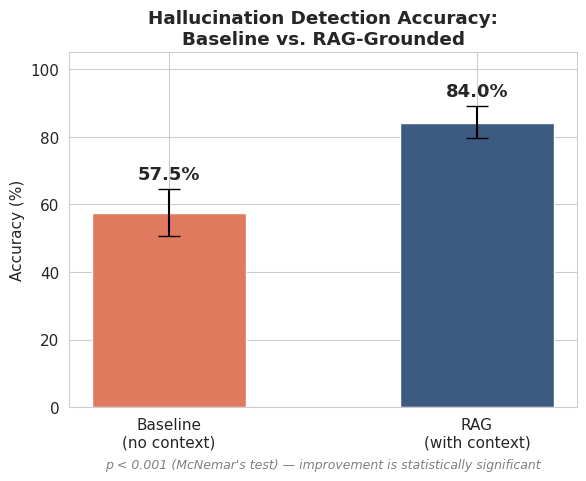

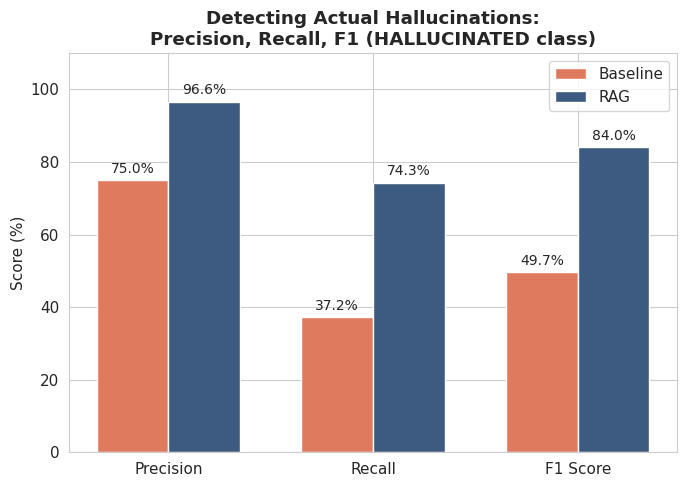

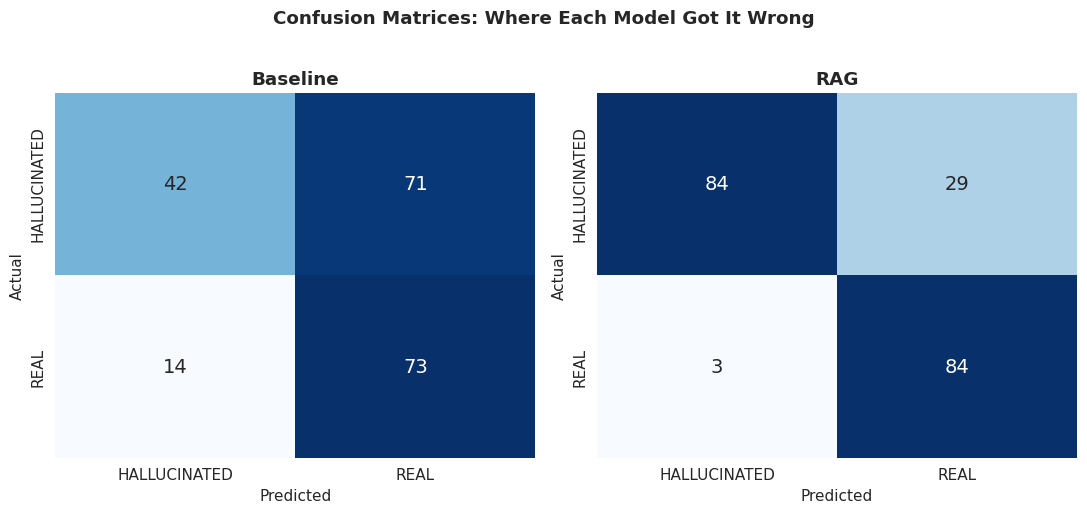

All 3 charts saved.


In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['font.size'] = 11

# ============================================
# CHART 1: Overall accuracy, baseline vs RAG
# ============================================
fig, ax = plt.subplots(figsize=(6, 5))
categories = ['Baseline\n(no context)', 'RAG\n(with context)']
values = [57.5, 84.0]
ci_lower = [50.5, 79.5]
ci_upper = [64.5, 89.0]
errors_below = [values[i] - ci_lower[i] for i in range(2)]
errors_above = [ci_upper[i] - values[i] for i in range(2)]
colors = ['#e07a5f', '#3d5a80']

bars = ax.bar(categories, values, color=colors, width=0.5)
ax.errorbar(categories, values, yerr=[errors_below, errors_above], fmt='none', ecolor='black', capsize=8, linewidth=1.5)

# label now placed ABOVE the error bar's upper limit, not above the bar
for i, (bar, val, upper) in enumerate(zip(bars, values, ci_upper)):
    ax.text(bar.get_x() + bar.get_width()/2, upper + 3, f'{val}%', ha='center', fontsize=13, fontweight='bold')

ax.set_ylabel('Accuracy (%)')
ax.set_title('Hallucination Detection Accuracy:\nBaseline vs. RAG-Grounded', fontweight='bold')
ax.set_ylim(0, 105)
ax.text(0.5, -18, 'p < 0.001 (McNemar\'s test) — improvement is statistically significant',
        ha='center', transform=ax.transData, fontsize=9, style='italic', color='gray')
plt.tight_layout()
plt.savefig('chart1_overall_accuracy.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================
# CHART 2: Precision, Recall, F1 for HALLUCINATED class — the one that matters most
# ============================================
fig, ax = plt.subplots(figsize=(7, 5))
metrics = ['Precision', 'Recall', 'F1 Score']
baseline_scores = [75.0, 37.2, 49.7]
rag_scores = [96.6, 74.3, 84.0]

x = range(len(metrics))
width = 0.35
ax.bar([i - width/2 for i in x], baseline_scores, width, label='Baseline', color='#e07a5f')
ax.bar([i + width/2 for i in x], rag_scores, width, label='RAG', color='#3d5a80')

for i, (b, r) in enumerate(zip(baseline_scores, rag_scores)):
    ax.text(i - width/2, b + 2, f'{b}%', ha='center', fontsize=10)
    ax.text(i + width/2, r + 2, f'{r}%', ha='center', fontsize=10)

ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylabel('Score (%)')
ax.set_title('Detecting Actual Hallucinations:\nPrecision, Recall, F1 (HALLUCINATED class)', fontweight='bold')
ax.set_ylim(0, 110)
ax.legend()
plt.tight_layout()
plt.savefig('chart2_precision_recall_f1.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================
# CHART 3: Confusion matrices side by side
# ============================================
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
baseline_cm = np.array([[42, 71], [14, 73]])
rag_cm = np.array([[84, 29], [3, 84]])
labels = ['HALLUCINATED', 'REAL']

for ax, cm, title in zip(axes, [baseline_cm, rag_cm], ['Baseline', 'RAG']):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=labels, yticklabels=labels, ax=ax, annot_kws={"size": 14})
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_title(title, fontweight='bold')

plt.suptitle('Confusion Matrices: Where Each Model Got It Wrong', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('chart3_confusion_matrices.png', dpi=300, bbox_inches='tight')
plt.show()

print("All 3 charts saved.")

In [22]:
def run_detection_safe(samples, choices, use_context, filename):
    results = []
    for i, (row, use_hallucinated) in enumerate(zip(samples, choices)):
        answer_to_test = row['Hallucinated Answer'] if use_hallucinated else row['Ground Truth']
        actual_label = "HALLUCINATED" if use_hallucinated else "REAL"

        if use_context:
            prompt = f"""Context (verified medical knowledge): {row['Knowledge']}

Question: {row['Question']}
Answer: {answer_to_test}

Based ONLY on the context provided above, is this answer factually correct or is it hallucinated (made up)? Reply with only one word: CORRECT or HALLUCINATED."""
        else:
            prompt = f"""Question: {row['Question']}
Answer: {answer_to_test}

Is this answer factually correct or is it hallucinated (made up)? Reply with only one word: CORRECT or HALLUCINATED."""

        messages = [{"role": "user", "content": prompt}]
        response = detector(messages, max_new_tokens=10, do_sample=False)
        model_says = response[0]['generated_text'][-1]['content'].strip()

        results.append({"question": row['Question'], "actual_label": actual_label,
                         "model_prediction": model_says, "difficulty": row['Difficulty Level']})

        if i % 100 == 0:
            pd.DataFrame(results).to_csv(filename, index=False)
            print(f"{'RAG' if use_context else 'Baseline'} - Processed {i}/1000, checkpoint saved...")

    pd.DataFrame(results).to_csv(filename, index=False)
    return pd.DataFrame(results)

full_samples = medhallu['train']
random.seed(42)
full_choices = [random.choice([True, False]) for _ in range(1000)]

baseline_1000 = run_detection_safe(full_samples, full_choices, use_context=False, filename="baseline_1000.csv")
rag_1000 = run_detection_safe(full_samples, full_choices, use_context=True, filename="rag_1000.csv")
print("Both done.")

Both `max_new_tokens` (=10) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=10) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Baseline - Processed 0/1000, checkpoint saved...


Both `max_new_tokens` (=10) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=10) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=10) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=10) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `ma

Baseline - Processed 100/1000, checkpoint saved...


Both `max_new_tokens` (=10) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=10) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=10) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=10) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `ma

...

RAG - Processed 800/1000, checkpoint saved...


Both `max_new_tokens` (=10) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=10) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=10) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=10) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `ma

RAG - Processed 900/1000, checkpoint saved...


Both `max_new_tokens` (=10) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=10) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=10) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=10) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `ma

Both done.


In [23]:
baseline_1000 = pd.read_csv("baseline_1000.csv")
rag_1000 = pd.read_csv("rag_1000.csv")

def full_analysis(df, label):
    df = df.copy()
    df['model_prediction_clean'] = df['model_prediction'].str.strip().str.rstrip('.').str.upper()
    df['actual_label_clean'] = df['actual_label'].str.strip().str.upper()
    label_map = {"CORRECT": "REAL", "HALLUCINATED": "HALLUCINATED"}
    df['model_prediction_mapped'] = df['model_prediction_clean'].map(label_map)
    df['correct'] = df['model_prediction_mapped'] == df['actual_label_clean']

    print(f"=== {label} (n={len(df)}) ===")
    print(f"Overall accuracy: {df['correct'].mean()*100:.1f}%")
    print(df.groupby('actual_label_clean')['correct'].mean() * 100)
    print(df.groupby('difficulty')['correct'].mean() * 100)
    print()
    return df

baseline_1000_analyzed = full_analysis(baseline_1000, "BASELINE - FULL 1000")
rag_1000_analyzed = full_analysis(rag_1000, "RAG - FULL 1000")

# McNemar's test on the full 1000
comparison_1000 = baseline_1000_analyzed[['question', 'correct']].rename(columns={'correct': 'baseline_correct'})
comparison_1000 = comparison_1000.merge(rag_1000_analyzed[['question', 'correct']].rename(columns={'correct': 'rag_correct'}), on='question')

both_correct = ((comparison_1000['baseline_correct']) & (comparison_1000['rag_correct'])).sum()
baseline_only = ((comparison_1000['baseline_correct']) & (~comparison_1000['rag_correct'])).sum()
rag_only = ((~comparison_1000['baseline_correct']) & (comparison_1000['rag_correct'])).sum()
both_wrong = ((~comparison_1000['baseline_correct']) & (~comparison_1000['rag_correct'])).sum()

table = [[both_correct, baseline_only], [rag_only, both_wrong]]
result = mcnemar(table, exact=True)
print(f"McNemar's p-value (n=1000): {result.pvalue:.10f}")

=== BASELINE - FULL 1000 (n=1000) ===
Overall accuracy: 64.0%
actual_label_clean
HALLUCINATED    38.888889
REAL            87.743191
Name: correct, dtype: float64
difficulty
easy      70.437956
hard      55.637255
medium    69.182390
Name: correct, dtype: float64

=== RAG - FULL 1000 (n=1000) ===
Overall accuracy: 80.5%
actual_label_clean
HALLUCINATED    69.958848
REAL            90.466926
Name: correct, dtype: float64
difficulty
easy      85.036496
hard      75.245098
medium    83.333333
Name: correct, dtype: float64

McNemar's p-value (n=1000): 0.0000000000


In [24]:
def get_metrics_1000(df, label):
    y_true = df['actual_label_clean']
    y_pred = df['model_prediction_mapped']
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, labels=['HALLUCINATED', 'REAL'], average=None
    )
    print(f"=== {label} ===")
    for i, cls in enumerate(['HALLUCINATED', 'REAL']):
        print(f"{cls}: Precision={precision[i]*100:.1f}%  Recall={recall[i]*100:.1f}%  F1={f1[i]*100:.1f}%")
    cm = confusion_matrix(y_true, y_pred, labels=['HALLUCINATED', 'REAL'])
    print(f"Confusion matrix [HALLUCINATED, REAL]:\n{cm}\n")

get_metrics_1000(baseline_1000_analyzed, "BASELINE - 1000")
get_metrics_1000(rag_1000_analyzed, "RAG - 1000")

=== BASELINE - 1000 ===
HALLUCINATED: Precision=75.0%  Recall=38.9%  F1=51.2%
REAL: Precision=60.3%  Recall=87.7%  F1=71.5%
Confusion matrix [HALLUCINATED, REAL]:
[[189 297]
 [ 63 451]]

=== RAG - 1000 ===
HALLUCINATED: Precision=87.4%  Recall=70.0%  F1=77.7%
REAL: Precision=76.1%  Recall=90.5%  F1=82.7%
Confusion matrix [HALLUCINATED, REAL]:
[[340 146]
 [ 49 465]]



Baseline 95% CI: 61.1%–66.9%
RAG 95% CI: 78.1%–83.0%


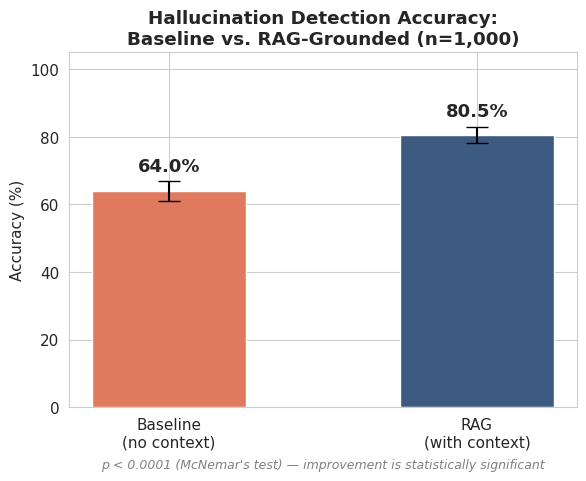

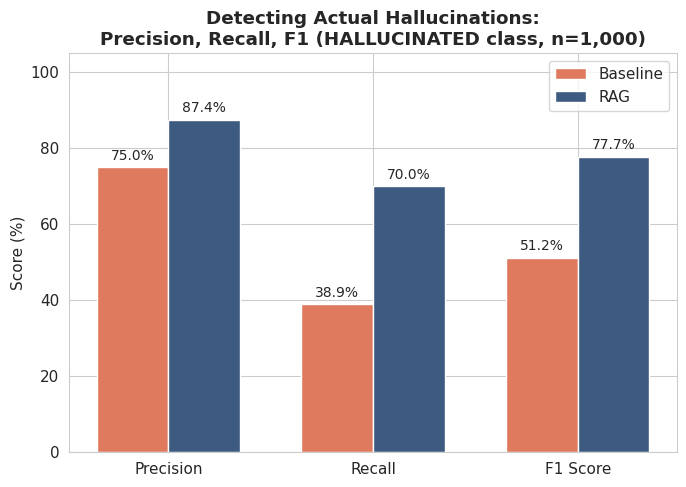

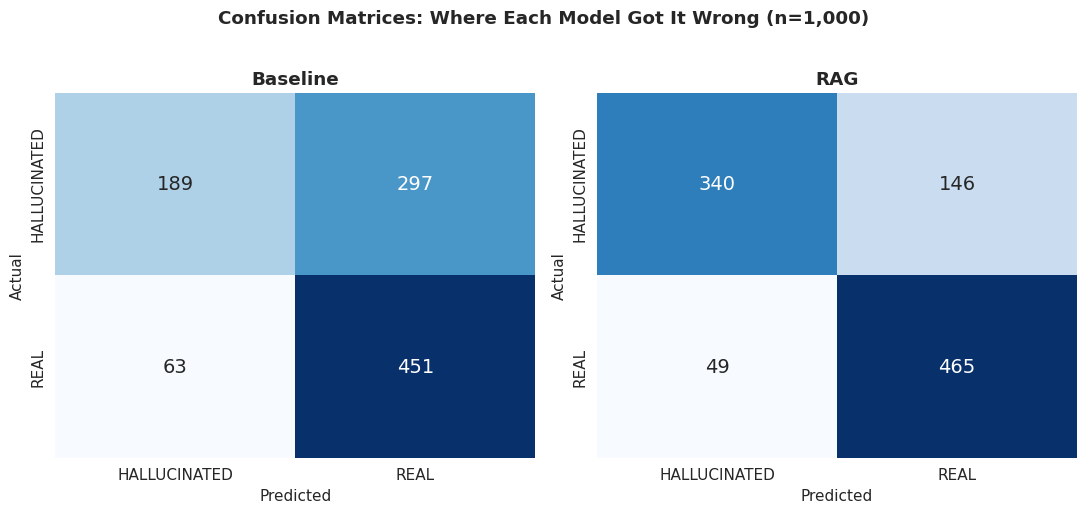

All 3 charts saved with final n=1,000 results.


In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_style("whitegrid")
plt.rcParams['font.size'] = 11

# Bootstrap CI for the 1000-sample accuracy, needed for chart 1's error bars
def bootstrap_ci(correct_series, n_bootstrap=1000):
    accuracies = []
    for _ in range(n_bootstrap):
        sample = correct_series.sample(frac=1, replace=True)
        accuracies.append(sample.mean())
    return np.percentile(accuracies, 2.5), np.percentile(accuracies, 97.5)

baseline_ci_1000 = bootstrap_ci(baseline_1000_analyzed['correct'])
rag_ci_1000 = bootstrap_ci(rag_1000_analyzed['correct'])
print(f"Baseline 95% CI: {baseline_ci_1000[0]*100:.1f}%–{baseline_ci_1000[1]*100:.1f}%")
print(f"RAG 95% CI: {rag_ci_1000[0]*100:.1f}%–{rag_ci_1000[1]*100:.1f}%")

# ============================================
# CHART 1: Overall accuracy, baseline vs RAG (n=1000)
# ============================================
fig, ax = plt.subplots(figsize=(6, 5))
categories = ['Baseline\n(no context)', 'RAG\n(with context)']
values = [64.0, 80.5]
ci_lower = [baseline_ci_1000[0]*100, rag_ci_1000[0]*100]
ci_upper = [baseline_ci_1000[1]*100, rag_ci_1000[1]*100]
errors_below = [values[i] - ci_lower[i] for i in range(2)]
errors_above = [ci_upper[i] - values[i] for i in range(2)]
colors = ['#e07a5f', '#3d5a80']

bars = ax.bar(categories, values, color=colors, width=0.5)
ax.errorbar(categories, values, yerr=[errors_below, errors_above], fmt='none', ecolor='black', capsize=8, linewidth=1.5)

for i, (bar, val, upper) in enumerate(zip(bars, values, ci_upper)):
    ax.text(bar.get_x() + bar.get_width()/2, upper + 3, f'{val}%', ha='center', fontsize=13, fontweight='bold')

ax.set_ylabel('Accuracy (%)')
ax.set_title('Hallucination Detection Accuracy:\nBaseline vs. RAG-Grounded (n=1,000)', fontweight='bold')
ax.set_ylim(0, 105)
ax.text(0.5, -18, "p < 0.0001 (McNemar's test) — improvement is statistically significant",
        ha='center', transform=ax.transData, fontsize=9, style='italic', color='gray')
plt.tight_layout()
plt.savefig('chart1_overall_accuracy.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================
# CHART 2: Precision, Recall, F1 for HALLUCINATED class (n=1000)
# ============================================
fig, ax = plt.subplots(figsize=(7, 5))
metrics = ['Precision', 'Recall', 'F1 Score']
baseline_scores = [75.0, 38.9, 51.2]
rag_scores = [87.4, 70.0, 77.7]

x = range(len(metrics))
width = 0.35
ax.bar([i - width/2 for i in x], baseline_scores, width, label='Baseline', color='#e07a5f')
ax.bar([i + width/2 for i in x], rag_scores, width, label='RAG', color='#3d5a80')

for i, (b, r) in enumerate(zip(baseline_scores, rag_scores)):
    ax.text(i - width/2, b + 2, f'{b}%', ha='center', fontsize=10)
    ax.text(i + width/2, r + 2, f'{r}%', ha='center', fontsize=10)

ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylabel('Score (%)')
ax.set_title('Detecting Actual Hallucinations:\nPrecision, Recall, F1 (HALLUCINATED class, n=1,000)', fontweight='bold')
ax.set_ylim(0, 105)
ax.legend()
plt.tight_layout()
plt.savefig('chart2_precision_recall_f1.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================
# CHART 3: Confusion matrices side by side (n=1000)
# ============================================
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
baseline_cm = np.array([[189, 297], [63, 451]])
rag_cm = np.array([[340, 146], [49, 465]])
labels = ['HALLUCINATED', 'REAL']

for ax, cm, title in zip(axes, [baseline_cm, rag_cm], ['Baseline', 'RAG']):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=labels, yticklabels=labels, ax=ax, annot_kws={"size": 14})
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_title(title, fontweight='bold')

plt.suptitle('Confusion Matrices: Where Each Model Got It Wrong (n=1,000)', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('chart3_confusion_matrices.png', dpi=300, bbox_inches='tight')
plt.show()

print("All 3 charts saved with final n=1,000 results.")